# Estimators / clocks — Pass 2.6

Four sampling clocks on the same venue-days: **calendar**, **trade**, **tick_bounce**, **mid**.

Pre-registered Promote for bounce domination: median fifth/fourth bootstrap **CI_lo > 1.5**.


In [1]:
from pathlib import Path
import json
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

BOOK = Path('/home/dev/srv/ares-microstructure/research/books/mn_tuwrv')
OUT = BOOK / 'out'
FIGS = OUT / 'desk_synthesis' / 'figs'
sys.path.insert(0, str(BOOK.parents[2]))  # research/

def jload(rel):
    return json.loads((OUT / rel).read_text())

def show_fig(name, caption=None):
    p = FIGS / name
    if caption:
        display(Markdown(f'**{caption}** — `{p.relative_to(BOOK)}`'))
    if p.exists():
        display(Image(filename=str(p)))
    else:
        display(Markdown(f'*missing figure* `{p}` — run `scripts/build_notebook_figs.py`'))

bc = jload('blocker_close/blocker_close.json')
gc = jload('gap_close/gap_close.json')
mc = jload('monte_carlo/mc_summary.json')
p2 = jload('pass2/pass2_gates.json')
print('BOOK', BOOK)
print('figs', sorted(p.name for p in FIGS.glob('*.png')))


BOOK /home/dev/srv/ares-microstructure/research/books/mn_tuwrv
figs ['fig_clock_medians.png', 'fig_gate_counts.png', 'fig_mc_rmse_ladder.png', 'fig_mid_venue_split.png', 'fig_noise_vs_spread.png', 'fig_noise_vs_spread_gap_close.png', 'fig_ratio_hist.png', 'fig_tob_coverage.png', 'fig_tsrv_oos.png', 'signal_board.png']


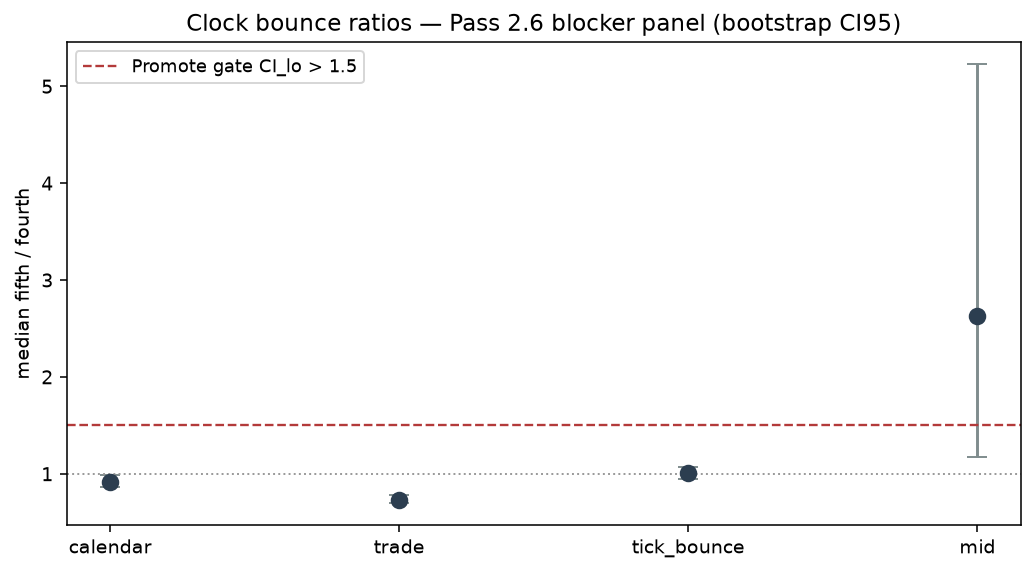

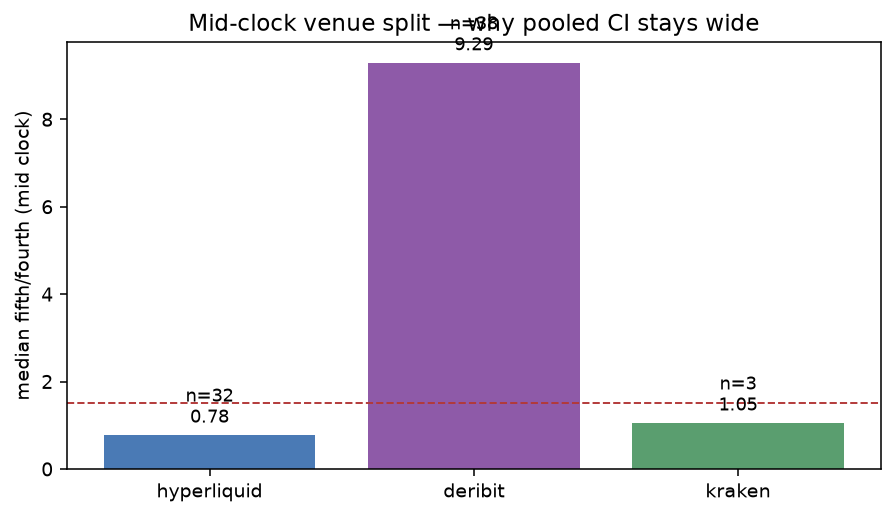

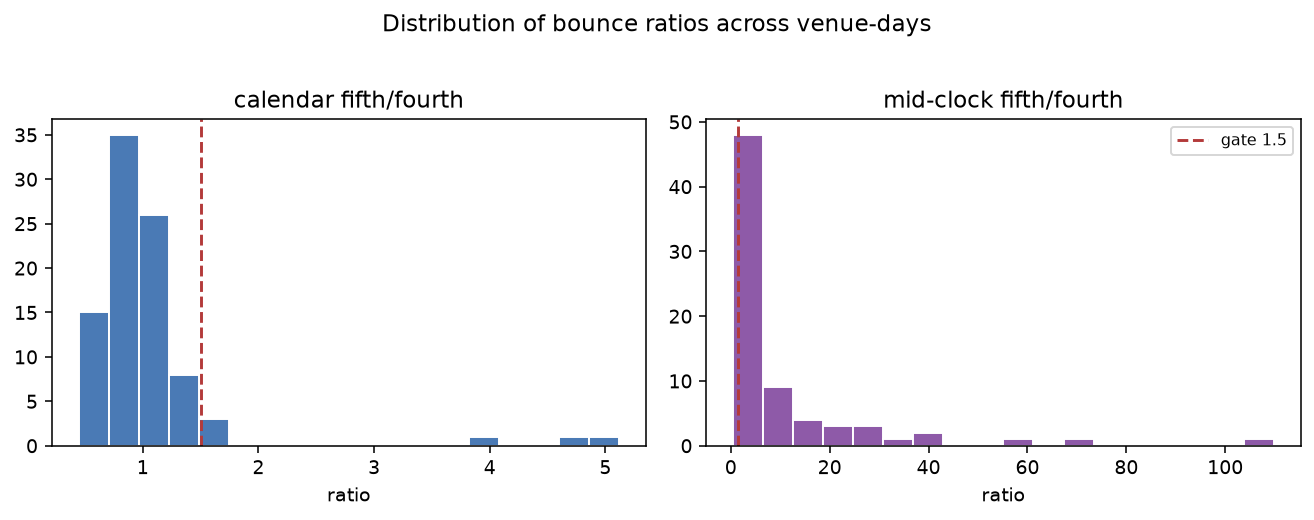

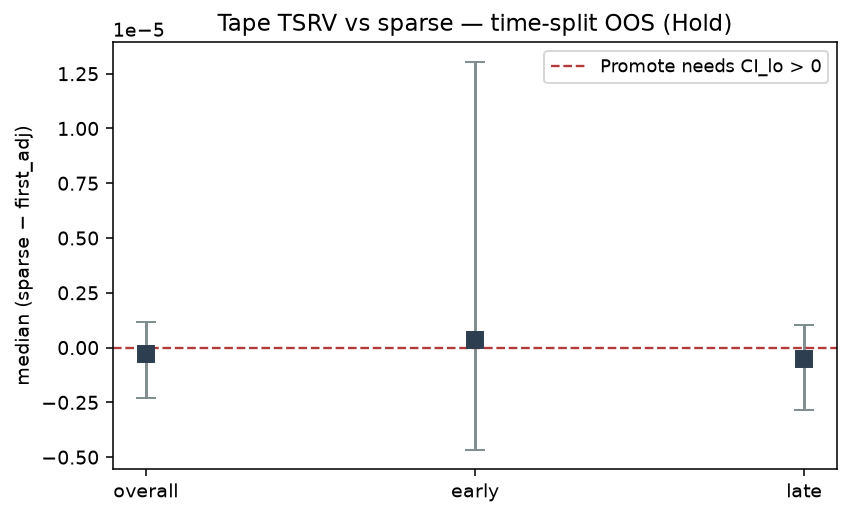

,clock,n,median,p10,p90,decision
0,calendar,90,0.914613,0.604411,1.293725,Kill
1,trade,90,0.725398,0.473468,0.985298,Kill
2,tick_bounce,90,1.011009,0.712692,1.352748,Kill
3,mid,73,2.628459,0.694830,26.327341,Hold


mid dense CI {'n': 73.0, 'median': 2.6284589596828876, 'mean': 10.007828439892164, 'se': 0.9714218276137652, 'ci95': [1.1720946380170352, 5.225043364195791]}
tsrv OOS gate Hold fragile_rate=0.011 adv_med=-2.75e-07 CI=[-2.306071822364372e-06, 1.1699299344884352e-06] SE=8.31e-07 earlyCI=[-4.654016190012627e-06, 1.3038927370727255e-05] lateCI=[-2.862172387962406e-06, 1.019566994153289e-06] ratio_med=1.0171 ratioCI=[0

 # Estimators — EXP_REPORT (Pass 2.6 blocker-close)

**`cont.tsrv_first_adj`:** **Hold** — fragile_rate=0.011 adv_med=-2.75e-07 CI=[-2.306071822364372e-06, 1.1699299344884352e-06] SE=8.31e-07 earlyCI=[-4.654016190012627e-06, 1.3038927370727255e-05] lateCI=[-2.862172387962406e-06, 1.019566994153289e-06] ratio_med=1.0171 ratioCI=[0.9594350796515484, 1.0516421957379292] roll_ci_lo_pos_frac=0.00 n=90 (MC Kill sparse still stands; Promote needs OOS CI_lo>0 early∧late)

- sparse−tsrv overall: {'n': 90.0, 'median': -2.747479641365083e-07, 'mean': -1.0759664019689518e-05, 'se': 8.30

In [2]:
show_fig('fig_clock_medians.png')
show_fig('fig_mid_venue_split.png')
show_fig('fig_ratio_hist.png')
show_fig('fig_tsrv_oos.png')

rows = [r for r in bc['rows'] if r.get('ok')]
summary = []
for clock, key in [('calendar','fifth_over_fourth_cal'),('trade','fifth_over_fourth_tc'),
                   ('tick_bounce','fifth_over_fourth_bounce'),('mid','fifth_over_fourth_mid')]:
    vals = np.asarray([r[key] for r in rows if np.isfinite(r.get(key, np.nan))], dtype=float)
    summary.append({
        'clock': clock, 'n': int(vals.size), 'median': float(np.median(vals)) if vals.size else np.nan,
        'p10': float(np.quantile(vals,0.1)) if vals.size else np.nan,
        'p90': float(np.quantile(vals,0.9)) if vals.size else np.nan,
        'decision': bc['mid_clock']['per_clock'][clock]['decision'],
    })
display(pd.DataFrame(summary))
print('mid dense CI', bc['mid_clock']['mid_dense_ci'])
print('tsrv OOS gate', bc['tsrv_oos']['gate']['decision'], bc['tsrv_oos']['gate']['why'][:240])
print('\n', (BOOK/'chapters/estimators/EXP_REPORT.md').read_text())


### Narrative

- Calendar / trade / tick_bounce: **Kill** — ratios sit near or below 1; no bounce domination.  
- Mid-clock: **Hold** — median ~2.6 looks interesting, but CI_lo=1.17 fails the pre-registered 1.5 gate; Deribit pulls the median up, HL does not.  
- `cont.tsrv_first_adj`: **Hold** — tape sparse−tsrv advantage CI includes 0 on early and late splits.
